In [2]:
import opendatasets as od
od.download('https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: authenticradio
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset


In [4]:
# Import Library
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision.datasets import ImageFolder
import torchvision.transforms.functional as F
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# Set Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
print(device)

cuda


In [7]:
train_path = '/content/brain-tumor-mri-dataset/Training'
test_path = '/content/brain-tumor-mri-dataset/Testing'

In [8]:
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [9]:
train_dataset = ImageFolder(train_path, transform=data_transforms)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

val_dataset = ImageFolder(test_path, transform=data_transforms)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [11]:
# Model Architecture
class BrainTumorClassifier(nn.Module):
  def __init__(self, num_classes):
    super().__init__()
    self.features = nn.Sequential(
        nn.Conv2d(3, 16, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(16, 32, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),
    )
    self.classifier = nn.Sequential(
        nn.Linear(32 * 56 * 56, 128),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.3),
        nn.Linear(128, num_classes),
    )

  def forward(self, x):
    x = self.features(x)
    x = x.view(x.size(0), -1)
    x = self.classifier(x)
    return x


In [12]:
model = BrainTumorClassifier(num_classes=4)
model.to(device)

BrainTumorClassifier(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=100352, out_features=128, bias=True)
    (1): ReLU(inplace=True)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=4, bias=True)
  )
)

In [13]:
# Define Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [14]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

In [15]:
# Training Loop
epochs = 25
best_val_accuracy = 0.0

for epoch in range(epochs):
  model.train()
  train_loss = 0.0
  correct = 0
  total = 0

  for batch_idx, (inputs, targets) in enumerate(train_loader):
    inputs, targets = inputs.to(device), targets.to(device)

    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, targets)
    loss.backward()
    optimizer.step()

    train_loss += loss.item()
    _, predicted = outputs.max(1)
    total += targets.size(0)
    correct += predicted.eq(targets).sum().item()

  train_accuracy = correct / total
  train_losses.append(train_loss / len(train_loader))
  train_accuracies.append(train_accuracy)

  model.eval()
  val_loss = 0.0
  correct = 0
  total = 0

  with torch.no_grad():
    for batch_idx, (inputs, targets) in enumerate(val_loader):
      inputs, targets = inputs.to(device), targets.to(device)

      outputs = model(inputs)
      loss = criterion(outputs, targets)
      val_loss += loss.item()

      _, predicted = outputs.max(1)
      total += targets.size(0)
      correct += predicted.eq(targets).sum().item()

  val_loss = val_loss / len(val_loader)
  val_losses.append(val_loss)
  val_accuracy = correct / total
  val_accuracies.append(val_accuracy)

  print(f'Epoch [{epoch+1}/{epochs}], '
          f'Training Loss: {train_loss:.4f}, Training Accuracy: {train_accuracy:.2%}, '
          f'Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.2%}')

  # Save the best model
  if val_accuracy > best_val_accuracy:
      best_val_accuracy = val_accuracy
      torch.save(model.state_dict(), 'best_model.pth')

Epoch [1/25], Training Loss: 235.4824, Training Accuracy: 76.42%, Validation Loss: 0.4144, Validation Accuracy: 81.92%
Epoch [2/25], Training Loss: 122.7679, Training Accuracy: 87.38%, Validation Loss: 0.3283, Validation Accuracy: 86.73%
Epoch [3/25], Training Loss: 94.4636, Training Accuracy: 90.00%, Validation Loss: 0.2055, Validation Accuracy: 92.52%
Epoch [4/25], Training Loss: 68.7101, Training Accuracy: 92.96%, Validation Loss: 0.2030, Validation Accuracy: 92.98%
Epoch [5/25], Training Loss: 62.8706, Training Accuracy: 93.89%, Validation Loss: 0.2373, Validation Accuracy: 91.53%
Epoch [6/25], Training Loss: 46.6265, Training Accuracy: 95.55%, Validation Loss: 0.1512, Validation Accuracy: 94.66%
Epoch [7/25], Training Loss: 38.8343, Training Accuracy: 96.22%, Validation Loss: 0.1210, Validation Accuracy: 95.58%
Epoch [8/25], Training Loss: 31.6134, Training Accuracy: 96.87%, Validation Loss: 0.1240, Validation Accuracy: 95.73%
Epoch [9/25], Training Loss: 31.3514, Training Accurac

In [16]:
accuracy = correct / total
print(f'Validation Accuracy: {accuracy:.2%}')

Validation Accuracy: 96.26%


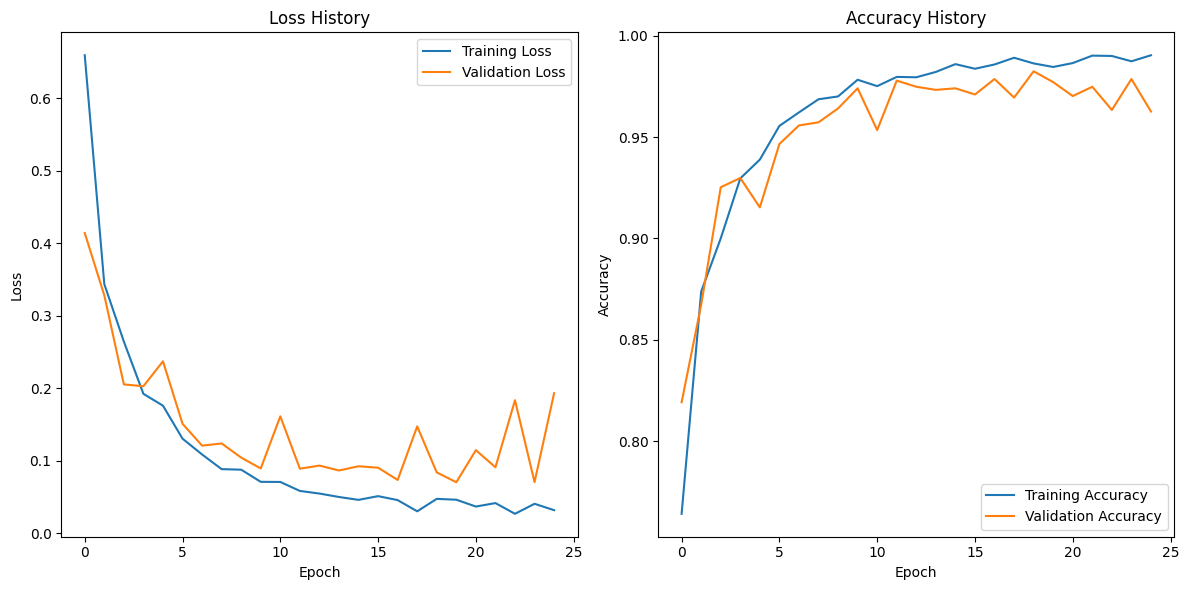

In [17]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss History')

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy History')

plt.tight_layout()
plt.show()